In [ ]:
#Meftuha kedir
#Abdi Mudesir


import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("oil_sales_assignment_dataset.csv")
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


In [27]:
print(df.tail())
print(len(df))
print(len(df.columns))
print("Numerical:", (df.select_dtypes(include='number').columns))
print("Categorical:", (df.select_dtypes(include='object').columns))

          city                                         store_name  \
1995     TABUK       HM No  99317  GS-CENTER-TABUK MAIN RD  TABUK   
1996   AL AHSA   HM No  85390  GS-CENTER-AL AHSA MAIN RD  AL AHSA   
1997  AL KHARJ  HM No  90740  GS-CENTER-AL KHARJ MAIN RD  AL K...   
1998    RIYADH     HM No  52893  GS-CENTER-RIYADH MAIN RD  RIYADH   
1999    JEDDAH     HM No  73689  GS-CENTER-JEDDAH MAIN RD  JEDDAH   

        manufacturer   brand      class   size                        sku  \
1995  NAJDI CONSUMER    LARA    COCONUT   0.5L  LARA COCONUT 0.5L PREMIUM   
1996   BLUE OASIS CO    LARA  SUNFLOWER     3L          LARA SUNFLOWER 3L   
1997      NOVA FOODS    NOUR  SUNFLOWER   2.9L        NOUR SUNFLOWER 2.9L   
1998      NOVA FOODS   NAJMA       CORN  0.75L       NAJMA CORN 0.75L ECO   
1999  NAJDI CONSUMER  BAYTNA    COCONUT   1.8L    BAYTNA COCONUT 1.8L ECO   

     price_bracket  year  month  value_sales  volume_sales  average_price  
1995         31-40  2024     11         74.4  

In [28]:
print(df.isnull().sum())
print(df.describe())

city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64
              year        month  value_sales  volume_sales  average_price
count  2000.000000  2000.000000  2000.000000   2000.000000    2000.000000
mean   2022.990500     6.639500   614.839355      9.972100      60.990230
std       0.820211     3.468942   750.794991      9.862369      29.457029
min    2022.000000     1.000000     6.960000      0.500000      11.000000
25%    2022.000000     4.000000   132.000000      2.900000      37.337500
50%    2023.000000     7.000000   368.320000      7.000000      61.000000
75%    2024.000000    10.000000   794.100000     13.800000      81.000000
max    2024.000000    12.000000  6253.200000     81.700000     140.000000


In [29]:
le = LabelEncoder()
cols = ['city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku', 'price_bracket']
for col in cols:
    df[col] = le.fit_transform(df[col])
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,1,302,5,3,1,3,537,2,2024,12,830.86,30.1,27.6
1,2,237,6,4,0,1,648,4,2024,10,373.10,9.1,41.0
2,8,1487,0,0,3,3,93,0,2023,1,171.70,1.7,101.0
3,3,1832,6,5,2,2,864,6,2022,2,1226.10,20.1,61.0
4,5,258,3,5,4,7,944,8,2024,2,996.30,12.3,81.0


In [30]:
X_univariate = df[['average_price']] 
y = df['value_sales']
X_train_uni, X_test_uni, y_train, y_test = train_test_split( X_univariate, y, test_size=0.2, random_state=42 ) 
print(f"Training set size: {X_train_uni.shape[0]}") 
print(f"Test set size: {X_test_uni.shape[0]}") 

Training set size: 1600
Test set size: 400


In [31]:
uni_model = LinearRegression() 
uni_model.fit(X_train_uni, y_train)
print("Univariate Linear Regression Model:") 
print(f"Equation: sales_Value = ${uni_model.intercept_:,.2f} + ${uni_model.coef_[0]:,.2f} * average_price") 
print(f"\nInterpretation: Each $1 increase in average_price increases value_sales by ${uni_model.coef_[0]:,.2f}")

Univariate Linear Regression Model:
Equation: sales_Value = $-27.28 + $10.51 * average_price

Interpretation: Each $1 increase in average_price increases value_sales by $10.51


In [ ]:
y_pred_uni_train = uni_model.predict(X_train_uni) 
y_pred_uni_test = uni_model.predict(X_test_uni) 

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_uni_train)) 
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_uni_test)) 
train_r2 = r2_score(y_train, y_pred_uni_train) 
test_r2 = r2_score(y_test, y_pred_uni_test) 
print("Univariate Model Performance:") 
print(f"Training RMSE: ${train_rmse:,.2f}") 
print(f"Test RMSE: ${test_rmse:,.2f}") 
print(f"Training R² Score: {train_r2:.4f}") 
print(f"Test R² Score: {test_r2:.4f}") 

Univariate Model Performance:
Training RMSE: $687.86
Test RMSE: $674.03
Training R² Score: 0.1735
Test R² Score: 0.1380


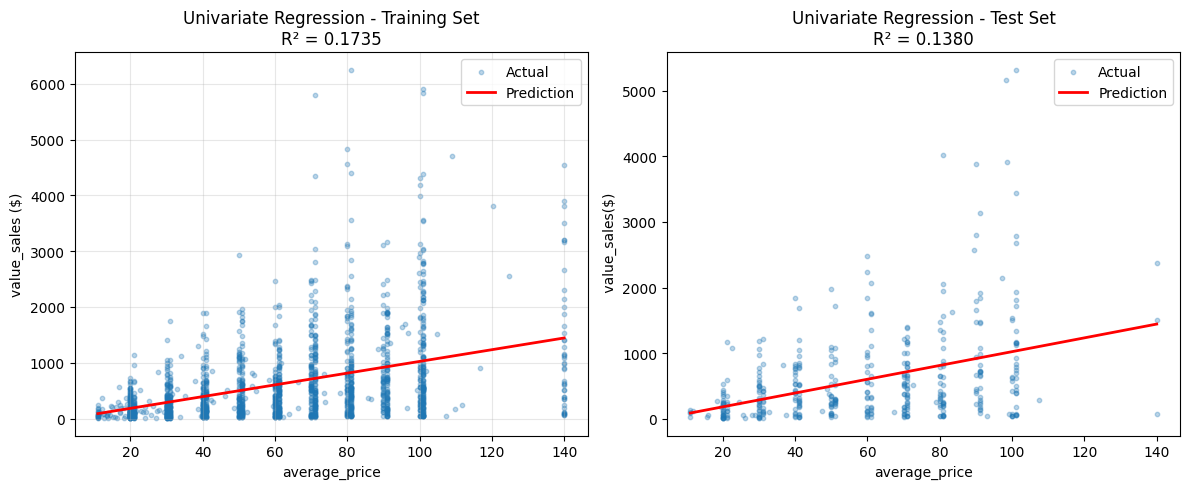

In [33]:
# Training data
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1) 
plt.scatter(X_train_uni, y_train, alpha=0.3, s=10, label='Actual') 
# FIXED: Create a sorted version for the line 
X_train_sorted = X_train_uni.sort_values('average_price') 
y_pred_sorted = uni_model.predict(X_train_sorted) 
plt.plot(X_train_sorted, y_pred_sorted, color='red', linewidth=2, 
label='Prediction') 
plt.xlabel('average_price') 
plt.ylabel('value_sales ($)') 
plt.title(f'Univariate Regression - Training Set\nR² = {train_r2:.4f}') 
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.grid(True, alpha=0.3) 
# Test data 
plt.subplot(1, 2, 2) 
plt.scatter(X_test_uni, y_test, alpha=0.3, s=10, label='Actual') 
# FIXED: Create a sorted version for the line 
X_test_sorted = X_test_uni.sort_values('average_price') 
y_pred_test_sorted = uni_model.predict(X_test_sorted) 
plt.plot(X_test_sorted, y_pred_test_sorted, color='red', linewidth=2, 
label='Prediction') 
plt.xlabel('average_price') 
plt.ylabel(' value_sales($)') #sales_Value
plt.title(f'Univariate Regression - Test Set\nR² = {test_r2:.4f}') 
plt.legend() 
plt.tight_layout() 
plt.show() 


In [34]:
# Select features for multivariate regression 
feature_cols = ['average_price', 'volume_sales', 'year',  
'month', 'city', 'manufacturer', 'brand',  
'class', 'price_bracket'] 
X_multivariate = df[feature_cols] 
y = df['value_sales'] 
print(f"Selected features: {feature_cols}") 
print(f"\nFeature matrix shape: {X_multivariate.shape}")


Selected features: ['average_price', 'volume_sales', 'year', 'month', 'city', 'manufacturer', 'brand', 'class', 'price_bracket']

Feature matrix shape: (2000, 9)


In [35]:
categorical_cols = [
    'city',
    'manufacturer',
    'brand',
    'class',
    'price_bracket'
]

# Apply label encoding
label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    X_multivariate[col] = encoder.fit_transform(X_multivariate[col])
    label_encoders[col] = encoder

C:\Users\j\AppData\Local\Temp\ipykernel_15608\1104106755.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_multivariate[col] = encoder.fit_transform(X_multivariate[col])
C:\Users\j\AppData\Local\Temp\ipykernel_15608\1104106755.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_multivariate[col] = encoder.fit_transform(X_multivariate[col])
C:\Users\j\AppData\Local\Temp\ipykernel_15608\1104106755.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [36]:
print(X_multivariate.head())

   average_price  volume_sales  year  month  city  manufacturer  brand  class  \
0           27.6          30.1  2024     12     1             5      3      1   
1           41.0           9.1  2024     10     2             6      4      0   
2          101.0           1.7  2023      1     8             0      0      3   
3           61.0          20.1  2022      2     3             6      5      2   
4           81.0          12.3  2024      2     5             3      5      4   

   price_bracket  
0              2  
1              4  
2              0  
3              6  
4              8  


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X_multivariate,
    y,
    test_size=0.2,
    random_state=42
)


In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_train_pred = model.predict(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)

# -----------------------------------
# 6. Calculate RMSE
# -----------------------------------

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

# -----------------------------------
# 7. Calculate R² Score
# -----------------------------------

train_r2 = r2_score(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)

# -----------------------------------
# 8. Display results
# -----------------------------------

print("Multivariate Model Performance:")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Training R² Score: {train_r2:.4f}")
print(f"Test R² Score: {test_r2:.4f}")

Multivariate Model Performance:
Training RMSE: $283.53
Test RMSE: $296.47
Training R² Score: 0.8596
Test R² Score: 0.8332


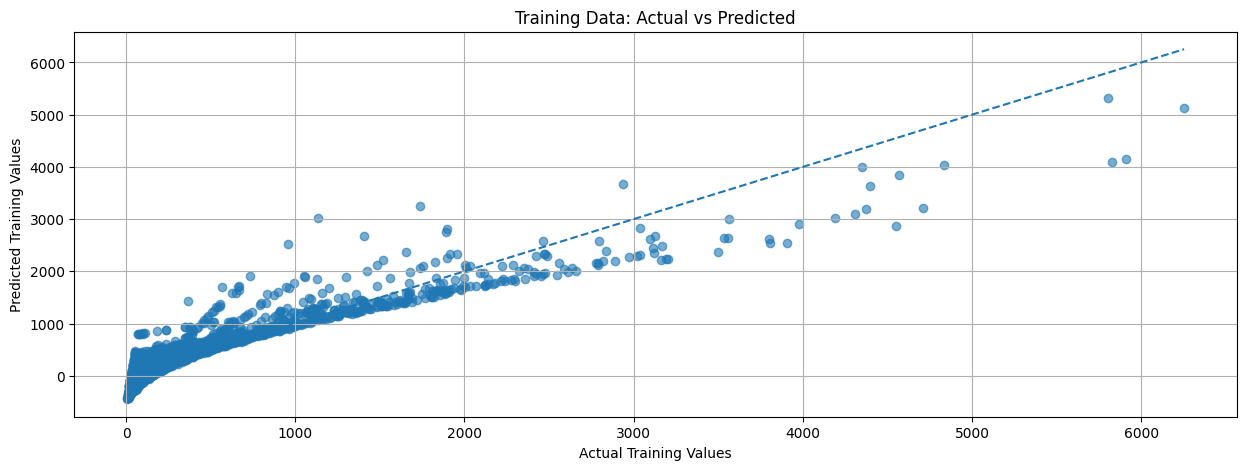

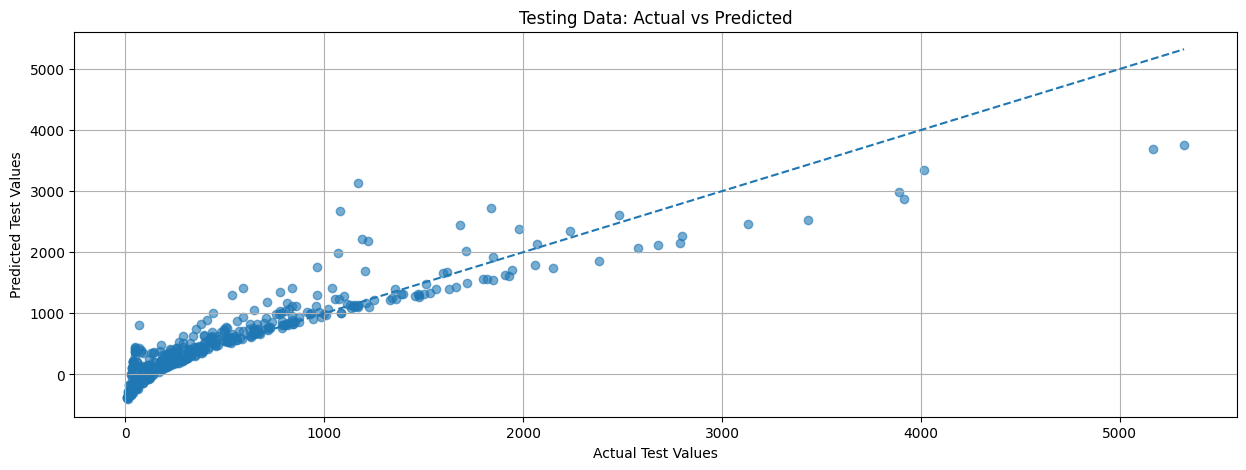

In [41]:
# -----------------------------------
# Training Scatter Plot
# -----------------------------------

plt.figure(figsize=(15, 5))

plt.scatter(
    y_train,
    y_train_pred,
    alpha=0.6
)

plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    linestyle="--"
)

plt.xlabel("Actual Training Values")
plt.ylabel("Predicted Training Values")

plt.title("Training Data: Actual vs Predicted")

plt.grid(True)

plt.show()


# -----------------------------------
# Testing Scatter Plot
# -----------------------------------

plt.figure(figsize=(15, 5))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Test Values")
plt.ylabel("Predicted Test Values")

plt.title("Testing Data: Actual vs Predicted")

plt.grid(True)

plt.show()

In [42]:
# ============================================
# Save Univariate Results
# ============================================

train_rmse_uni = np.sqrt(
    mean_squared_error(y_train, y_pred_uni_train)
)

test_rmse_uni = np.sqrt(
    mean_squared_error(y_test, y_pred_uni_test)
)

train_r2_uni = r2_score(
    y_train,
    y_pred_uni_train
)

test_r2_uni = r2_score(
    y_test,
    y_pred_uni_test
)

In [43]:
# ============================================
# Save Multivariate Results
# ============================================

train_rmse_multi = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse_multi = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

train_r2_multi = r2_score(
    y_train,
    y_train_pred
)

test_r2_multi = r2_score(
    y_test,
    y_test_pred
)

In [44]:
comparison_df = pd.DataFrame({
    "Model": [
        "Univariate Linear Regression",
        "Multivariate Linear Regression"
    ],

    "Number of Features": [
        1,
        len(feature_cols)
    ],

    "Training RMSE": [
        train_rmse_uni,
        train_rmse_multi
    ],

    "Test RMSE": [
        test_rmse_uni,
        test_rmse_multi
    ],

    "Training R²": [
        train_r2_uni,
        train_r2_multi
    ],

    "Test R²": [
        test_r2_uni,
        test_r2_multi
    ]
})

comparison_df

,Model,Number of Features,Training RMSE,Test RMSE,Training R²,Test R²
0,Univariate Linear Regression,1,687.860668,674.033619,0.173491,0.138022
1,Multivariate Linear Regression,9,283.527990,296.467283,0.859577,0.833242


In [45]:
# Save the trained model
joblib.dump(model, "model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

# Save the encoders
joblib.dump(label_encoders, "encoders.pkl")

print("Model, scaler, and encoders saved successfully.")

Model, scaler, and encoders saved successfully.
